# XAU/USD Real Data: HMM-AR(1) Model

Two fitting setups:
1. **Clipped days**: each day clipped to 02:00–22:00 UTC, treated as independent (sum of log-likelihoods)
2. **Stitched series**: all clipped days concatenated into one long series

Returns are scaled to pips (×10 000).


## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from methods.data_utils import load_data, pre_avg, compute_returns, filter_day
from methods.hmm_utils import (
    fit_single_ar1, predict_single_ar1,
    fit_hmm_robust, fit_hmm_multiday,
    predict_hmm_mixture, get_filtered_probs,
    evaluate_predictions
)
from methods.plotting import set_style

set_style()


## Load and prepare data

Clip each weekday to 02:00–22:00 UTC, pre-average with k=10 ticks,
compute returns and scale to pips.


In [2]:
K_TICKS    = 10
CLIP_START = "02:00"
CLIP_END   = "22:00"
MIN_OBS    = 100

df_raw = load_data(market="XAUUSD")

all_days = sorted(set(df_raw.index.normalize().date))
weekdays = [d for d in all_days if d.weekday() < 5]

segments = []
for day in weekdays:
    day_df = filter_day(df_raw, str(day))
    day_df = day_df.between_time(CLIP_START, CLIP_END)
    if len(day_df) < MIN_OBS:
        continue
    tmp = pre_avg(day_df, tick=True, k=K_TICKS)
    tmp = compute_returns(tmp)
    r = tmp["r"].values.astype(float) * 10_000  # to pips
    if len(r) >= MIN_OBS:
        segments.append(r)

print(f"Days used : {len(segments)}")
print(f"Avg obs/day: {np.mean([len(s) for s in segments]):.0f}")


Days used : 20
Avg obs/day: 32686


## Setup 1: Clipped independent days

Fit K=2 and K=3 using `fit_hmm_multiday`, which sums log-likelihoods across
days — equivalent to assuming days are independent.


In [3]:
results_s1 = {}

for K in [2, 3]:
    print(f"Fitting K={K} (setup 1) ...", end=" ")
    _, params = fit_hmm_multiday(segments, K=K, n_starts=3, seed=42)
    results_s1[K] = params
    print("done")


Fitting K=2 (setup 1) ... done
Fitting K=3 (setup 1) ... done


In [4]:
for K in [2, 3]:
    params = results_s1[K]
    print(f"\n--- Setup 1 | K={K} ---")
    print(f"  beta  : {np.round(params['beta'], 4)}")
    print(f"  sigma : {np.round(params['sigma'], 4)}")
    print(f"  P     :\n{np.round(params['P'], 4)}")



--- Setup 1 | K=2 ---
  beta  : [0.2085 0.2733]
  sigma : [2768.2636 8947.117 ]
  P     :
[[0.9201 0.0799]
 [0.2168 0.7832]]

--- Setup 1 | K=3 ---
  beta  : [0.2668 0.2522 0.1634]
  sigma : [11757.1153  4487.7503  1705.2018]
  P     :
[[0.7741 0.2259 0.    ]
 [0.0447 0.8185 0.1368]
 [0.0022 0.2095 0.7883]]


### Filtered state probabilities — Setup 1

Returns (left) and filtered state probabilities (right) for 4 sample days.


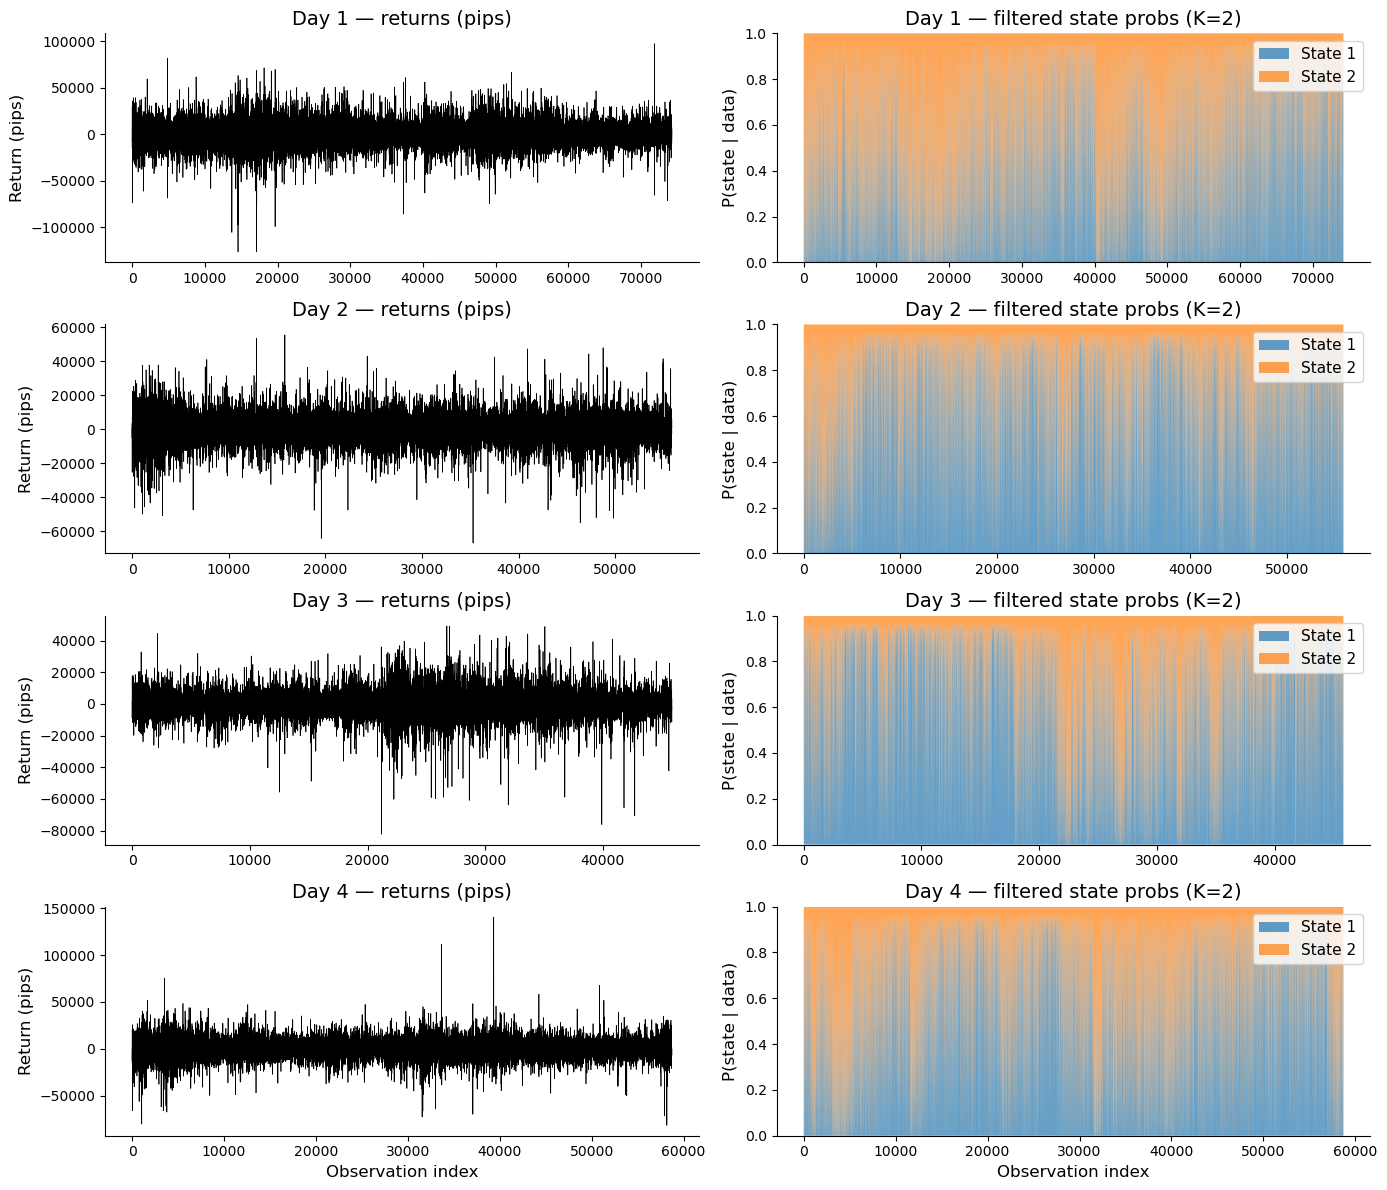

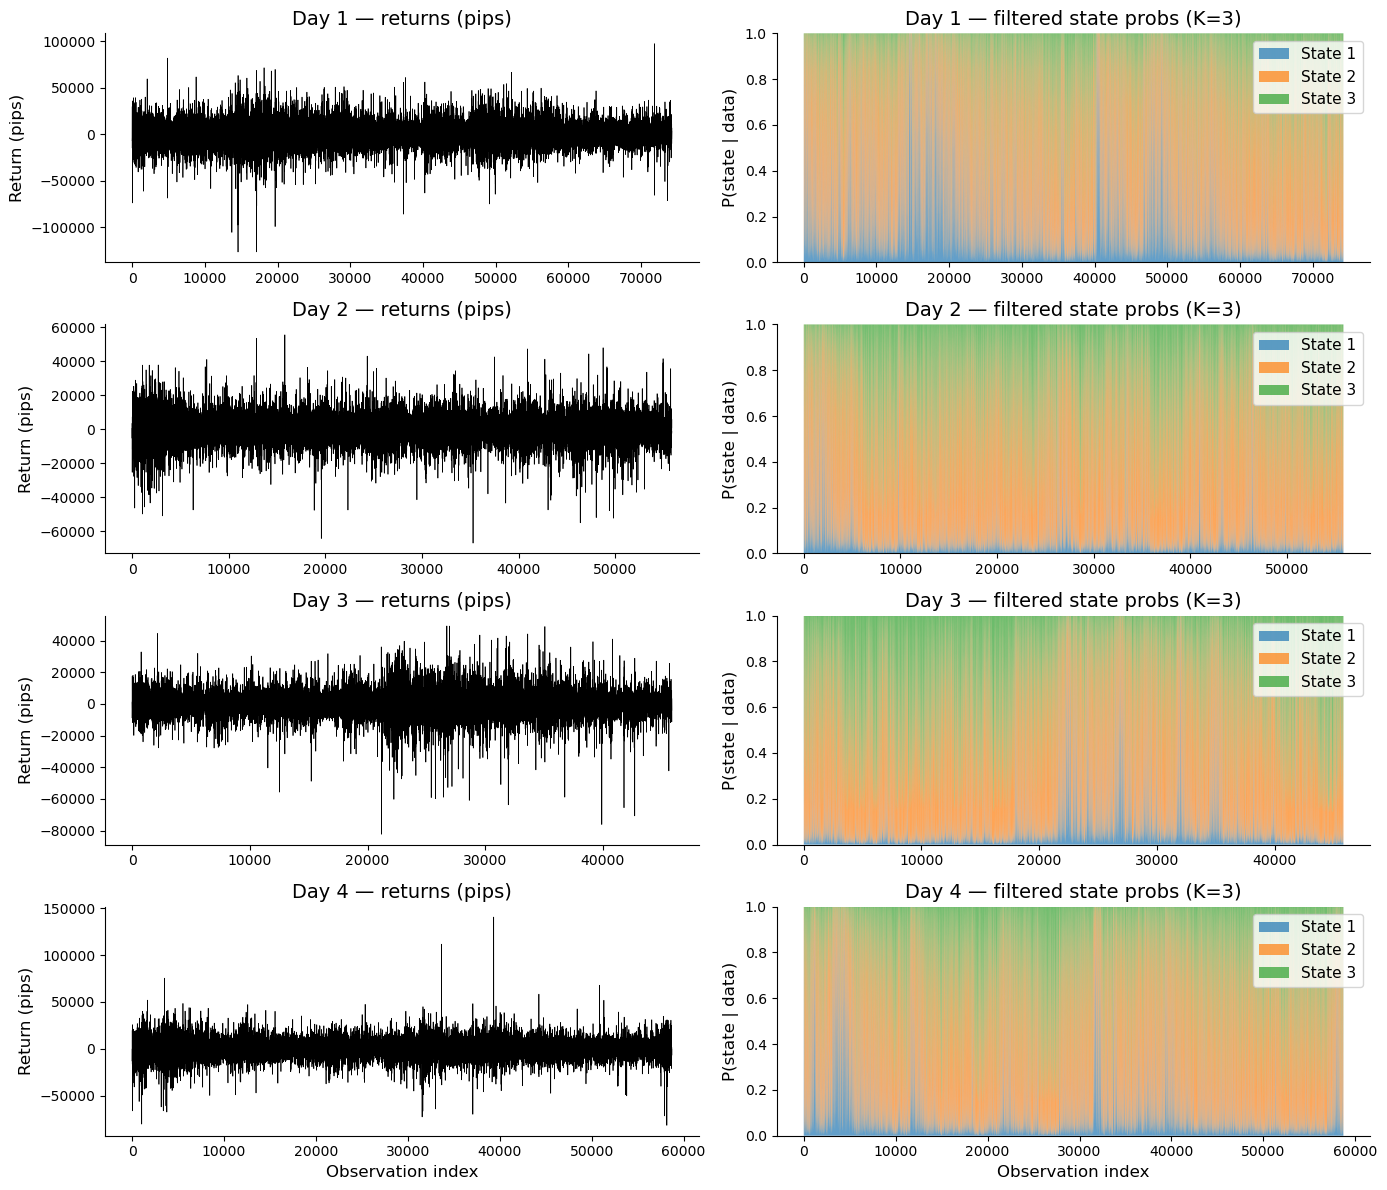

In [5]:
for K in [2, 3]:
    params = results_s1[K]
    n_plot = min(4, len(segments))

    fig, axes = plt.subplots(n_plot, 2, figsize=(14, 3 * n_plot))

    for i in range(n_plot):
        seg = segments[i]
        alpha = get_filtered_probs(seg, params)
        t = np.arange(len(seg))

        axes[i, 0].plot(t, seg, linewidth=0.5, color="black")
        axes[i, 0].set_title(f"Day {i+1} — returns (pips)")
        axes[i, 0].set_ylabel("Return (pips)")

        bottom = np.zeros(len(t))
        for j in range(K):
            top = bottom + alpha[:, j]
            axes[i, 1].fill_between(t, bottom, top, alpha=0.7, label=f"State {j+1}")
            bottom = top
        axes[i, 1].set_ylim(0, 1)
        axes[i, 1].set_title(f"Day {i+1} — filtered state probs (K={K})")
        axes[i, 1].set_ylabel("P(state | data)")
        axes[i, 1].legend(loc="upper right")

    axes[-1, 0].set_xlabel("Observation index")
    axes[-1, 1].set_xlabel("Observation index")
    plt.tight_layout()
    plt.savefig(f"../plots/xauusd_filtered_probs_s1_K{K}.pdf", bbox_inches="tight")
    plt.show()


## Setup 2: Stitched series

Concatenate all clipped daily segments into one long series.
Train on first 80%, test on last 20%.


In [6]:
TRAIN_FRAC = 0.8

y_full = np.concatenate(segments)
split  = int(TRAIN_FRAC * len(y_full))
y_train, y_test = y_full[:split], y_full[split:]

print(f"Total obs    : {len(y_full):,}")
print(f"Train / Test : {len(y_train):,} / {len(y_test):,}")


Total obs    : 653,716
Train / Test : 522,972 / 130,744


### Fit models on training data



In [7]:
rho_hat, sigma_hat_ar1 = fit_single_ar1(y_train)

results_s2 = {}
for K in [2, 3]:
    print(f"Fitting K={K} (setup 2) ...", end=" ")
    _, params = fit_hmm_robust(y_train, K=K, n_starts=10, seed=42)
    results_s2[K] = params
    print("done")


Fitting K=2 (setup 2) ... done
Fitting K=3 (setup 2) ... done


In [8]:
print("AR(1):")
print(f"  rho   : {rho_hat:.4f}")
print(f"  sigma : {sigma_hat_ar1:.4f}")

for K in [2, 3]:
    params = results_s2[K]
    print(f"\n--- Setup 2 | K={K} ---")
    print(f"  beta  : {np.round(params['beta'], 4)}")
    print(f"  sigma : {np.round(params['sigma'], 4)}")
    print(f"  P     :\n{np.round(params['P'], 4)}")


AR(1):
  rho   : 0.2516
  sigma : 5594.8516

--- Setup 2 | K=2 ---
  beta  : [0.2044 0.2771]
  sigma : [2938.1255 9445.2128]
  P     :
[[0.9057 0.0943]
 [0.2414 0.7586]]

--- Setup 2 | K=3 ---
  beta  : [0.2676 0.1507 0.2555]
  sigma : [12441.4619  1731.2688  4785.5759]
  P     :
[[0.7414 0.0011 0.2574]
 [0.0042 0.746  0.2498]
 [0.0503 0.1508 0.7989]]


### Filtered state probabilities — Setup 2

First 500 observations of the test set.


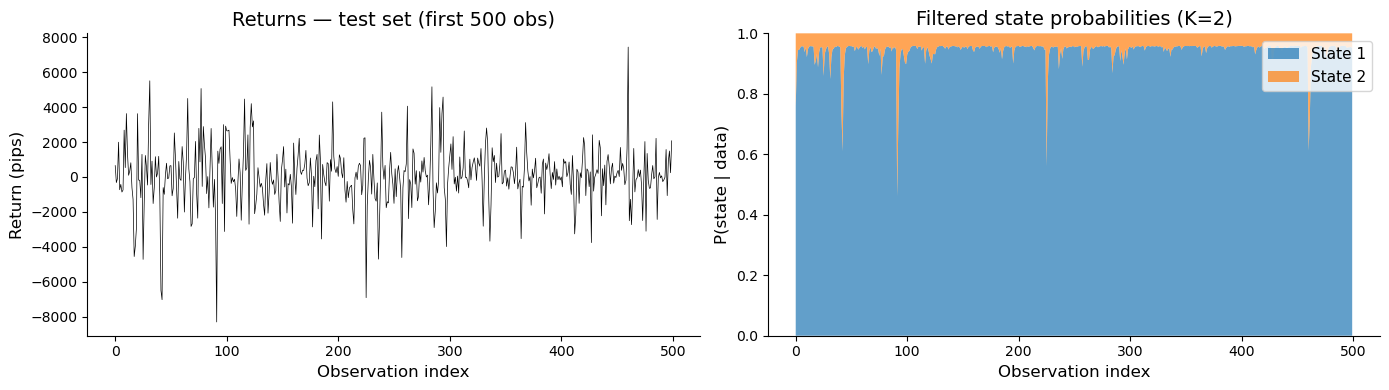

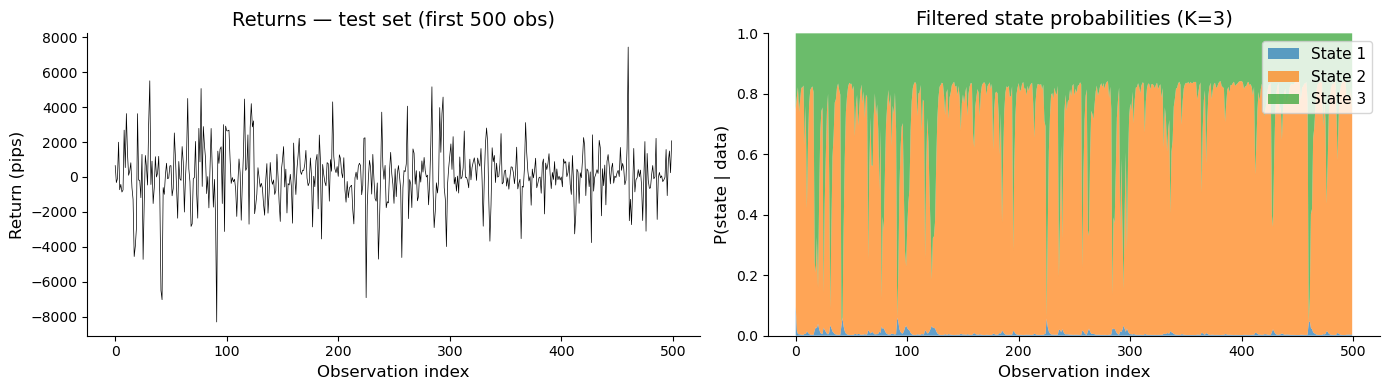

In [9]:
n_show = 500
t = np.arange(n_show)

for K in [2, 3]:
    alpha = get_filtered_probs(y_test, results_s2[K])

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(t, y_test[:n_show], linewidth=0.5, color="black")
    axes[0].set_title("Returns — test set (first 500 obs)")
    axes[0].set_xlabel("Observation index")
    axes[0].set_ylabel("Return (pips)")

    bottom = np.zeros(n_show)
    for j in range(K):
        top = bottom + alpha[:n_show, j]
        axes[1].fill_between(t, bottom, top, alpha=0.7, label=f"State {j+1}")
        bottom = top
    axes[1].set_ylim(0, 1)
    axes[1].set_title(f"Filtered state probabilities (K={K})")
    axes[1].set_xlabel("Observation index")
    axes[1].set_ylabel("P(state | data)")
    axes[1].legend(loc="upper right")

    plt.tight_layout()
    plt.savefig(f"../plots/xauusd_filtered_probs_s2_K{K}.pdf", bbox_inches="tight")
    plt.show()


### Prediction intervals — Setup 2

One-step-ahead 95% prediction intervals on test data.
Compare AR(1) vs HMM mixture (K=2 and K=3).


In [10]:
pred_ar1, lower_ar1, upper_ar1 = predict_single_ar1(
    y_train, y_test, rho_hat, sigma_hat_ar1, alpha=0.05
)

preds = {"AR(1)": (pred_ar1, lower_ar1, upper_ar1)}
for K in [2, 3]:
    pred, lower, upper = predict_hmm_mixture(
        y_train, y_test, results_s2[K], alpha=0.05
    )
    preds[f"HMM mixture K={K}"] = (pred, lower, upper)


In [11]:
eval_rows = {}
for label, (pred, lower, upper) in preds.items():
    eval_rows[label] = evaluate_predictions(y_test, pred, lower, upper, alpha=0.05)

pd.DataFrame(eval_rows).T.round(4)


,rmse,coverage,avg_width,interval_score
AR(1),3272.8410,0.9913,21931.4152,23183.3698
HMM mixture K=2,3275.3055,0.9850,18643.8309,20395.0200
HMM mixture K=3,3275.1874,0.9808,17548.7317,19629.5865


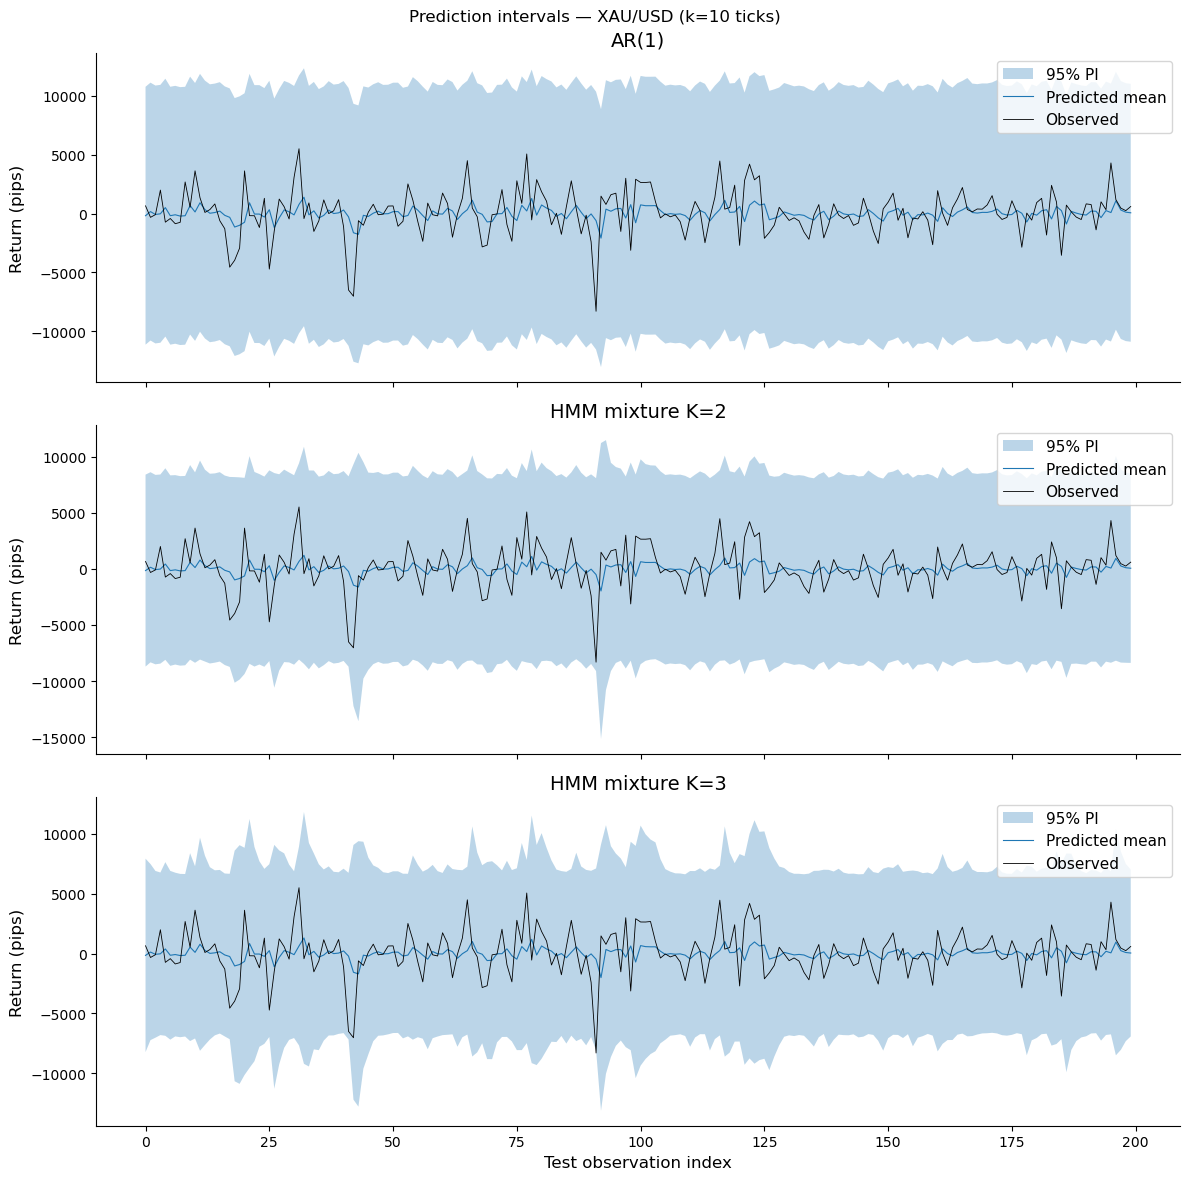

In [12]:
n_show = 200
t_plot = np.arange(n_show)

fig, axes = plt.subplots(len(preds), 1, figsize=(12, 4 * len(preds)), sharex=True)

for ax, (label, (pred, lower, upper)) in zip(axes, preds.items()):
    ax.fill_between(t_plot, lower[:n_show], upper[:n_show], alpha=0.3, label="95% PI")
    ax.plot(t_plot, pred[:n_show], linewidth=0.8, label="Predicted mean")
    ax.plot(t_plot, y_test[:n_show], linewidth=0.6, color="black", label="Observed")
    ax.set_title(label)
    ax.set_ylabel("Return (pips)")
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Test observation index")
fig.suptitle(f"Prediction intervals — XAU/USD (k={K_TICKS} ticks)")
plt.tight_layout()
plt.savefig("../plots/xauusd_prediction_intervals.pdf", bbox_inches="tight")
plt.show()


## Vary pre-averaging level k

Repeat Setup 2 for k ∈ {5, 10, 20, 50} ticks. Compare interval score across models.


In [13]:
k_values = [5, 10, 20, 50]
vary_k_results = []

for k in k_values:
    segs = []
    for day in weekdays:
        day_df = filter_day(df_raw, str(day))
        day_df = day_df.between_time(CLIP_START, CLIP_END)
        if len(day_df) < MIN_OBS:
            continue
        tmp = pre_avg(day_df, tick=True, k=k)
        tmp = compute_returns(tmp)
        r = tmp["r"].values.astype(float) * 10_000
        if len(r) >= MIN_OBS:
            segs.append(r)

    y = np.concatenate(segs)
    sp = int(TRAIN_FRAC * len(y))
    y_tr, y_te = y[:sp], y[sp:]

    rho, sig = fit_single_ar1(y_tr)
    p_ar1, l_ar1, u_ar1 = predict_single_ar1(y_tr, y_te, rho, sig, alpha=0.05)
    ar1_e = evaluate_predictions(y_te, p_ar1, l_ar1, u_ar1, alpha=0.05)
    vary_k_results.append({"k": k, "method": "AR(1)", "n_obs": len(y), **ar1_e})

    for K in [2, 3]:
        _, params = fit_hmm_robust(y_tr, K=K, n_starts=10, seed=42)
        p_mix, l_mix, u_mix = predict_hmm_mixture(y_tr, y_te, params, alpha=0.05)
        mix_e = evaluate_predictions(y_te, p_mix, l_mix, u_mix, alpha=0.05)
        vary_k_results.append({"k": k, "method": f"HMM mixture K={K}", "n_obs": len(y), **mix_e})

    print(f"k={k:>2d}  n={len(y):>6,}  done")

vary_k_df = pd.DataFrame(vary_k_results).round(4)


k= 5  n=1,307,441  done
k=10  n=653,716  done
k=20  n=326,852  done
k=50  n=130,735  done


In [14]:
vary_k_df


,k,method,n_obs,rmse,coverage,avg_width,interval_score
0,5,AR(1),1307441,2355.1454,0.9897,15642.4937,16828.4907
1,5,HMM mixture K=2,1307441,2358.0413,0.9850,13978.2303,15463.0802
2,5,HMM mixture K=3,1307441,2357.5396,0.9813,13154.0967,14882.8254
3,10,AR(1),653716,3272.8410,0.9913,21931.4152,23183.3698
4,10,HMM mixture K=2,653716,3275.3055,0.9850,18643.8309,20395.0200
5,10,HMM mixture K=3,653716,3275.1874,0.9808,17548.7317,19629.5865
6,20,AR(1),326852,4615.7968,0.9927,31149.5285,32513.7878
7,20,HMM mixture K=2,326852,4617.3142,0.9836,24892.5019,27238.6135
8,20,HMM mixture K=3,326852,4617.2106,0.9756,22501.8881,25686.1835
9,50,AR(1),130735,7303.6438,0.9935,48885.9107,50738.1884
